In [21]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Load the JSON file
with open('../data/results/evolution_history.json', 'r') as f:
    history = json.load(f)
    f.close()

print(f"Solution {history['best_overall']} found in generation {history['generations_taken_for_optimal']}")

# Example: Convert a specific generation's species data into a Pandas DataFrame
#gen_0_species = history['species']['0']
#df_species = pd.DataFrame(gen_0_species)
#df_species.head()

Solution atan((x0 / 8.04e+00)) found in generation 466


In [23]:
generations = [int(g) for g in list(history['species'].keys())]
generations.sort()
generations = np.array(generations)
print(f"Generations: {generations}")

Generations: [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530
 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710
 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890
 900 910 920 930 940 950 960 970 980 990]


In [24]:
species_id_to_idx = {}
idx_to_species_id = {}
idx_to_expression = {}
idx = 0
for gen in generations:
	for species in history['species'][str(gen)]:
		if species['id'] not in species_id_to_idx:
			species_id_to_idx[species['id']] = idx
			idx_to_species_id[idx] = species['id']
			idx += 1
		idx_to_expression[species_id_to_idx[species['id']]] = species['representative']
print(f"Unique species count: {len(species_id_to_idx)}")

Unique species count: 28


In [25]:
species_sizes_over_time = np.zeros((len(generations), len(species_id_to_idx)), dtype=int)
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		species_sizes_over_time[gi, species_idx] = species['size']

In [26]:
idxs = np.argsort(species_sizes_over_time[-1])
for idx in idxs[-10:]:
	print(f"Species {idx_to_species_id[idx]} with size {species_sizes_over_time[-1][idx]}: {idx_to_expression[idx]}")

Species 39 with size 0: asin(x1)
Species 40 with size 0: (-5.16e+00 mod x1)
Species 12 with size 0: ((x0 / 9.09e+00) mod (((7.38e-02 / ((sin(sin((-4.08e+00 mod (-4.69e+00 / x0)))) mod 8.19e-01) mod 8.19e-01)) - 9.04e-02) / -2.98e-03))
Species 36 with size 0: sin((-8.83e+00 min cos(x1)))
Species 35 with size 2: sin((-3.00e+00 min cos(x1)))
Species 44 with size 3: (x1 mod x1)
Species 26 with size 3: sin(((cos((5.74e+00 / ((exp(sin((9.49e+00 ^ ((x1 min -9.98e-01) / 2.26e+00)))) * 4.82e+00) / -9.52e+00))) + x0) / 8.78e+00))
Species 1 with size 25: 4.84e-05
Species 2 with size 26: sin((((abs(x0) mod x0) + x0) / 8.78e+00))
Species 0 with size 41: atan((x0 / 8.04e+00))


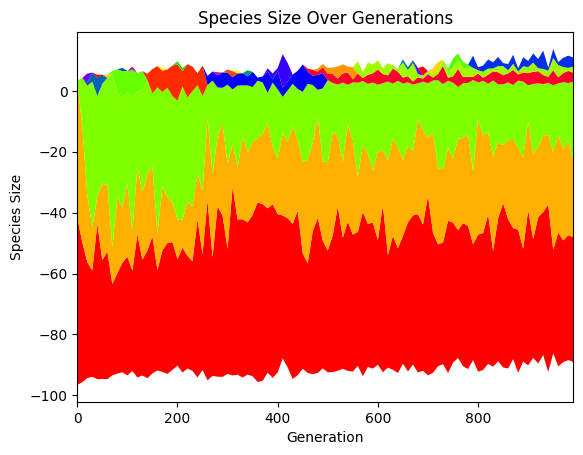

In [27]:
fig, ax = plt.subplots()
cmap = plt.get_cmap('prism')
cols = [cmap((i%50) / 50) for i in range(len(species_id_to_idx))]
ax.stackplot(generations, species_sizes_over_time.T, colors=cols, baseline='wiggle')

ax.set(xlim=(generations[0], generations[-1]))#, ylim=(0, np.max(species_sizes_over_time, axis=1)[0]))
ax.set_xlabel('Generation')
ax.set_ylabel('Species Size')
ax.set_title('Species Size Over Generations')
plt.show()

In [28]:
print(history['species']['0'][0].keys())

dict_keys(['id', 'size', 'representative', 'loss_raws', 'complexities', 'loss_insts', 'loss_finals'])


In [29]:
data_over_time = np.ones((4, 3, len(generations), len(species_id_to_idx)))*np.nan
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		for idx, name in {0:'loss_raws',1:'complexities',2:'loss_insts',3:'loss_finals'}.items():
			for jdx,fnc in {0:np.min,1:np.median,2:np.max}.items():
				arr = np.array(species[name]).astype(float)
				if np.isnan(arr).any():
					print(f"NaN found in {name} for species {species['id']} in generation {gen}")
				if np.isinf(arr).any():
					print(f"Inf found in {name} for species {species['id']} in generation {gen}")
				y = np.array(fnc([species[name]])).astype(float)
				if np.isnan(y):
					print(f"NaN found after aggregation in {name} for species {species['id']} in generation {gen}")
				elif np.isinf(y):
					print(f"Inf found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
				elif y > 1e6:
					#print(f"Unrealistically high value {y} found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
					data_over_time[idx, jdx, gi, species_idx] = np.nan
				else:
					data_over_time[idx, jdx, gi, species_idx] = y

Inf found after aggregation using median in loss_raws for species 38 in generation 680
Inf found after aggregation using median in loss_finals for species 38 in generation 680
Inf found after aggregation using median in loss_raws for species 44 in generation 790
Inf found after aggregation using median in loss_finals for species 44 in generation 790


/tmp/ipykernel_136971/2764759316.py:1: RuntimeWarning: All-NaN slice encountered
  average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])


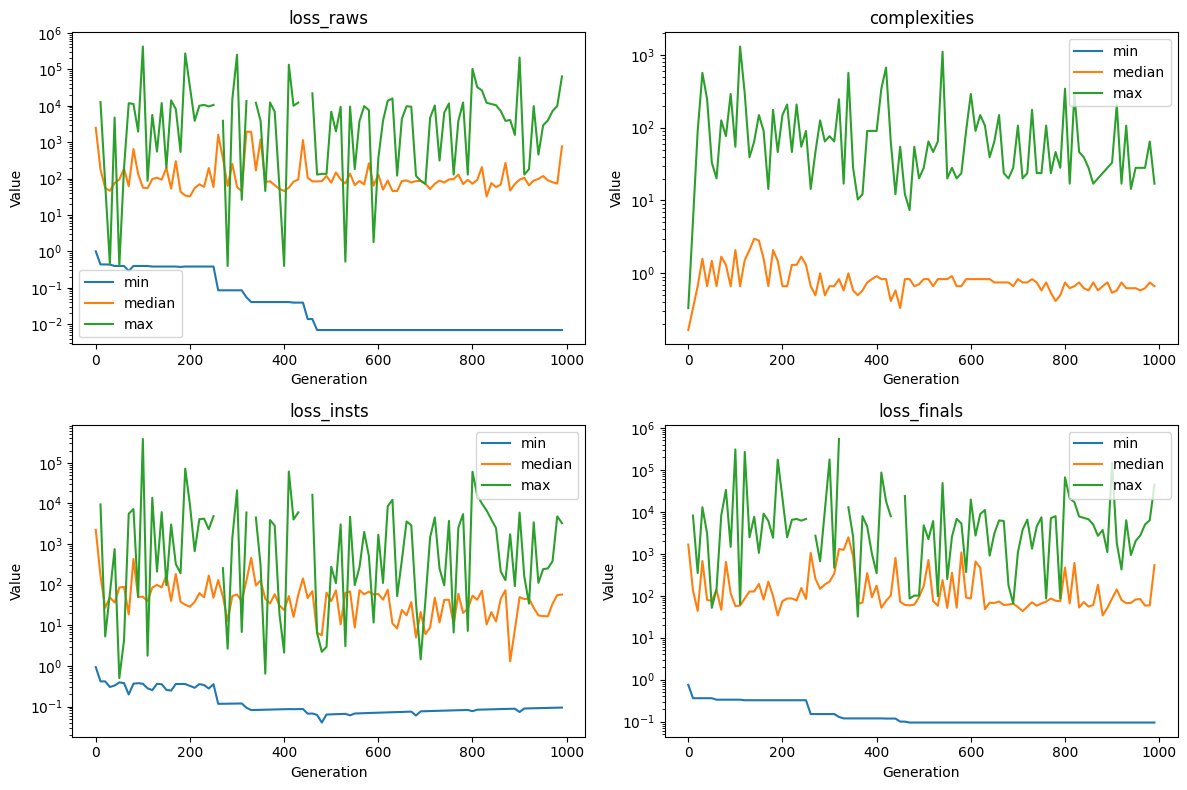

In [30]:
average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])
average_data_over_time = np.transpose(average_data_over_time, (1, 0,2))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
metric_names = ['loss_raws', 'complexities', 'loss_insts', 'loss_finals']
for idx in range(4):
	for jdx in range(3) if idx == 1 else range(3):
		ax[idx//2, idx%2].semilogy(generations, average_data_over_time[idx, jdx], label=['min', 'median', 'max'][jdx])
	ax[idx//2, idx%2].set_title(metric_names[idx])
	ax[idx//2, idx%2].set_xlabel('Generation')
	ax[idx//2, idx%2].set_ylabel('Value')
	ax[idx//2, idx%2].legend()
plt.tight_layout()
plt.show()